In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

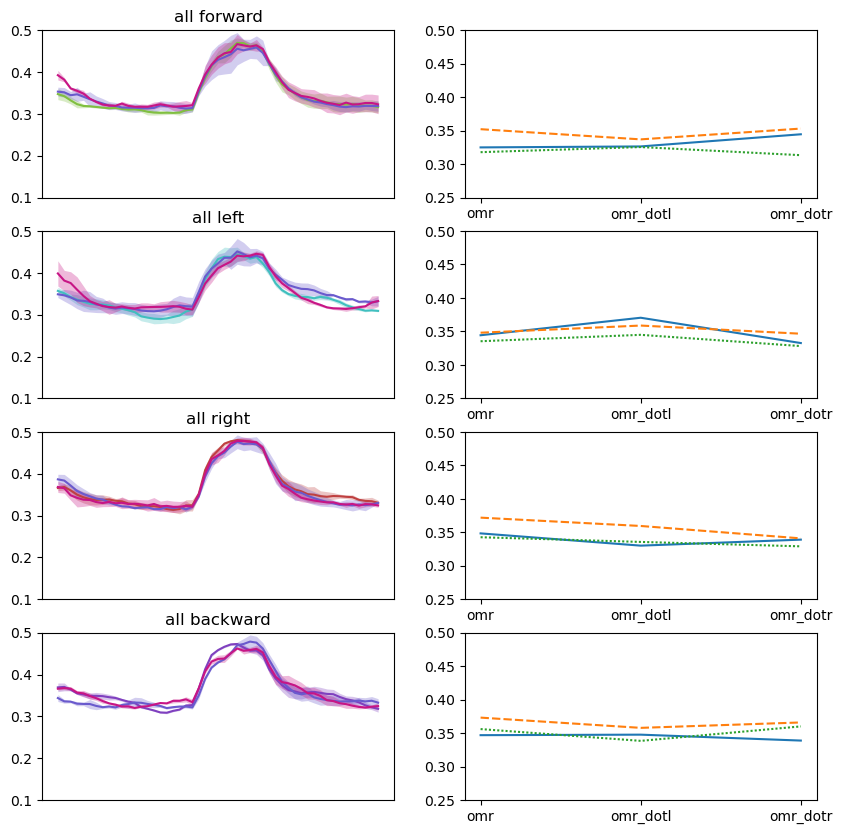

In [156]:
paths = [
         r"C:\Data\Imaging\250912_overlap\fish15",
r"C:\Data\Imaging\250912_overlap\fish13",
r"C:\Data\Imaging\250912_overlap\fish14"]
# paths =      [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish3_overlap"]
# paths = [   r"C:\Data\Imaging\251224_overlap\fish3_HB",
# r"C:\Data\Imaging\251224_overlap\fish5",
# r"C:\Data\Imaging\251224_overlap\fish5_HB",
# r"C:\Data\Imaging\251224_overlap\fish1",
# r"C:\Data\Imaging\251224_overlap\fish1_HB",
# r"C:\Data\Imaging\251224_overlap\fish2",
# r"C:\Data\Imaging\251224_overlap\fish2_HB",
# r"C:\Data\Imaging\251224_overlap\fish3"]

regions = ['all']#['forebrain', 'hindbrain']
f_dict = {r: [] for r in regions}
for r in regions:
    for path in paths:
        f = pd.read_csv(path + f'//Graphs//grating_{r}neurons_highDSI.csv', index_col = 0).reset_index().rename(columns={'index': 'stim'})
        f_dict[r].append(f)
    f_dict[r] = pd.concat(f_dict[r])
fig = plot_line(f_dict)
plt.savefig(r"C:\Data\Imaging\250912_overlap\All_imaging//grating_neurons_highDSI.svg")
plt.show()
plt.close()

In [152]:
def plot_oppline(f_dict):
    omr_stims = ['forward', 'left', 'right', 'backward']
    fig, ax = plt.subplots(len(omr_stims), len(f_dict) * 2, figsize=(10, 10))
    for r_n, (r, f) in enumerate(f_dict.items()):
        for stim_n, stim in enumerate(omr_stims):
            ax_line = ax[stim_n, r_n * 2]
            ax_scatter = ax[stim_n, r_n * 2 + 1]
            ax_line.set_title(f"{r} {stim}")

            f_max = []
            for dot_stim_n, (dot_stim, c) in enumerate(
                    zip([None, 'dot_l', 'dot_r', 'blah'], [utils.omr_colors[stim], 'slateblue', 'mediumvioletred', 'grey'])):
                if dot_stim == None:
                    real_stim = stim
                elif dot_stim == 'blah':
                    real_stim = utils.angles_omr[(utils.omr_angles[stim] + 180)%360] + '_opp'
                else:
                    real_stim = str([dot_stim, stim])

                #get f
                f_stim = f[f.stim == real_stim].drop('stim', axis=1)
                f_mean = f_stim.mean(axis=0)
                f_sem = f_stim.std(axis=0)  #/ np.sqrt(f_stim.shape[0])
                ax_line.plot(f_mean, c=c)
                ax_line.fill_between(np.arange(len(f_mean)), f_mean - f_sem, f_mean + f_sem, color=c, alpha=0.3,
                                     linewidth=0)
                ax_line.set_ylim([0.25, 0.5])
                ax_line.set_xticks([])
                ax_line.set_xticklabels([])

                f_max.append(list(f_stim.iloc[:, 40:].max(axis = 1)))
            f_max = pd.DataFrame(np.array(f_max).T, columns=['omr', 'omropp_dotl', 'omropp_dotr', 'omropp'])
            sns.lineplot(f_max.T, ax = ax_scatter, color="dimgrey", linestyle="-",  legend = False)
            ax_scatter.set_ylim([0.3, 0.4])

    return fig

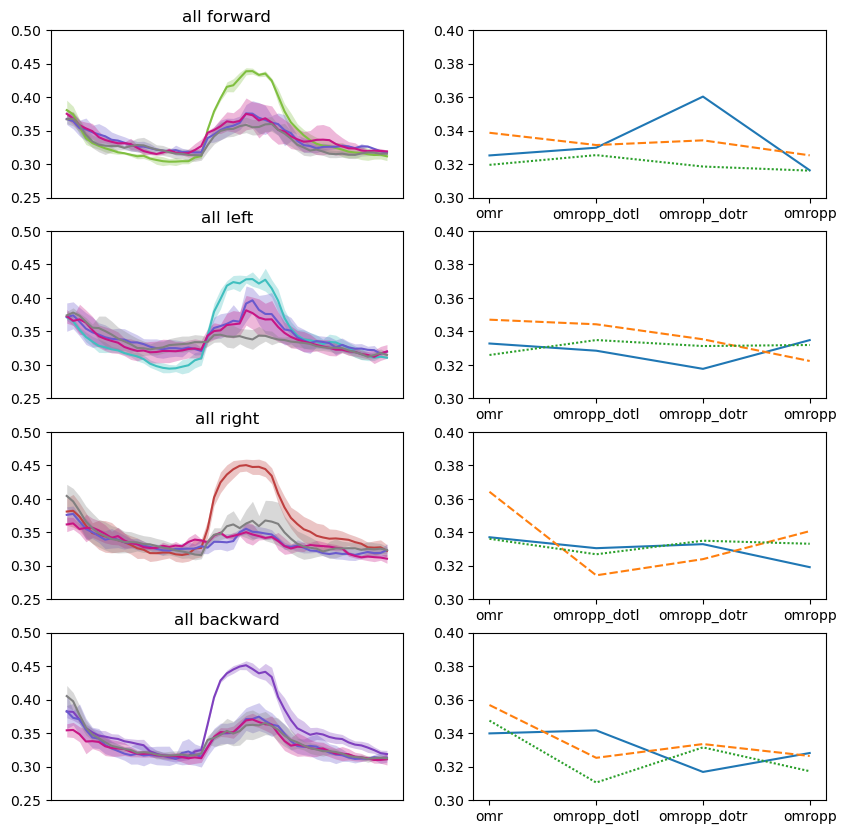

In [154]:
paths = [
#     r"C:\Data\Imaging\250912_overlap\fish3",
# r"C:\Data\Imaging\250912_overlap\fish2_2",
#          r"C:\Data\Imaging\250912_overlap\fish5_2",
#          r"C:\Data\Imaging\250912_overlap\fish9",
# r"C:\Data\Imaging\250912_overlap\fish8",
         r"C:\Data\Imaging\250912_overlap\fish15",
r"C:\Data\Imaging\250912_overlap\fish13",
r"C:\Data\Imaging\250912_overlap\fish14"]
# paths = [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
#          r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
#          r"C:\Data\Imaging\251021_dotsweep\fish3_overlap"]
# paths = [   r"C:\Data\Imaging\251224_overlap\fish3_HB",
# r"C:\Data\Imaging\251224_overlap\fish5",
# r"C:\Data\Imaging\251224_overlap\fish5_HB",
# r"C:\Data\Imaging\251224_overlap\fish1",
# r"C:\Data\Imaging\251224_overlap\fish1_HB",
# r"C:\Data\Imaging\251224_overlap\fish2",
# r"C:\Data\Imaging\251224_overlap\fish2_HB",
# r"C:\Data\Imaging\251224_overlap\fish3"]

regions =['all']#['forebrain', 'hindbrain']
f_dict = {r: [] for r in regions}
for r in regions:
    for path in paths:
        f = pd.read_csv(path + f'//Graphs//oppgrating_{r}neurons.csv', index_col=0).reset_index().rename(
            columns={'index': 'stim'})
        f_dict[r].append(f)
    f_dict[r] = pd.concat(f_dict[r])
fig = plot_oppline(f_dict)
plt.savefig(r"C:\Data\Imaging\250912_overlap\All_imaging//grating_neuronsopp.svg")
plt.show()
plt.close()